In [1]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner import RandomSearch, Hyperband
from keras_tuner.engine.hyperparameters import HyperParameters
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
import keras.regularizers
import keras
import glob
import os
import itertools
import fnmatch
import matplotlib.pyplot as plt

In [2]:
os.chdir('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/all_data/сsd_structures/')
files_calc = glob.glob('*.dat')
files_exp = glob.glob('*processed.gr')

In [3]:
raw_data_points = []

with open('labels.txt', 'w') as labels:
    for f in files_calc:
        if 'processed' in f:
            # For files containing 'processed' in their names (second type)
            df = pd.read_csv(f, usecols=[1], skiprows=1, header=None, delim_whitespace=True, skipfooter=1, engine='python')
        else:
            # For files not containing 'processed' in their names (first type)
            df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=0, engine='python')

        raw_data_points.append(df.values.ravel())
        labels.write(f[0])
        labels.write('\n')

raw_data_points = np.array(raw_data_points)

# Load the labels
labels = pd.read_csv("labels.txt", header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

6


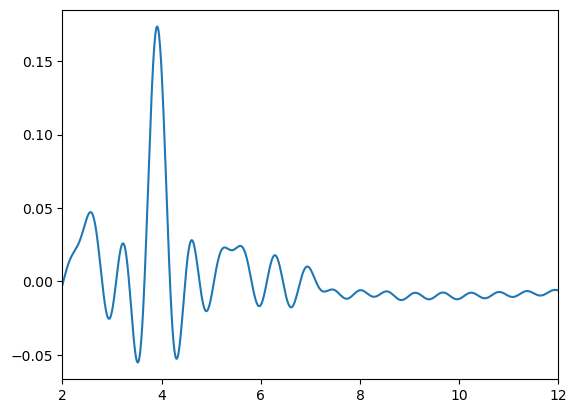

In [4]:
normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[55,:]))/100+2, data_points[55,:])
print(labels[55])

In [5]:
def create_model():
    model = Sequential()
    model.add(Conv1D(filters=16, kernel_size=64, activation='relu', input_shape=(1000, 1)))
    model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
    #model.add(BatchNormalization())
    #model.add(MaxPooling1D(pool_size=2))
    #model.add(Dropout(0.3))
    #model.add(Conv1D(filters=16, kernel_size=16, activation='relu'))
    model.add(Flatten())
    model.add(Dense(units=128, activation='relu'))
    #model.add(Dropout(0.3))
    model.add(Dense(units=10, activation='softmax'))
    optimizer = Adam(learning_rate=0.005)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

In [6]:
num_folds = 10
num_epochs = 200
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
fold_num = 1  # to keep track of which fold you're on
all_fold_results = []  # list to store performance metrics for each fold

In [7]:
for train_index, val_index in kf.split(data_points):
    X_train, X_val = data_points[train_index], data_points[val_index]
    y_train, y_val = labels[train_index], labels[val_index]
    
    model = create_model()
    
    checkpoint_name = f"simpler_fold_{fold_num}_model.hdf5"
    checkpoint = ModelCheckpoint(checkpoint_name, monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
    
    print(f'Training fold {fold_num}...')
    model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])
    
    # Load the best model saved by the checkpoint and evaluate
    with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
        load_model = keras.models.load_model(checkpoint_name)
        
    val_loss, val_acc = load_model.evaluate(X_val, y_val)
    print(f'Fold {fold_num} accuracy:', val_acc)
    
    all_fold_results.append(val_acc)
    
    fold_num += 1

# Print overall performance across all folds
print('All fold accuracies:', all_fold_results)
print('Mean accuracy:', np.mean(all_fold_results))
print('Standard deviation:', np.std(all_fold_results))

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 937, 16)           1040      
                                                                 
 seq_self_attention (SeqSelf  (None, 937, 16)          257       
 Attention)                                                      
                                                                 
 flatten (Flatten)           (None, 14992)             0         
                                                                 
 dense (Dense)               (None, 128)               1919104   
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1,921,691
Trainable params: 1,921,691
Non-trainable params: 0
______________________________________________

2023-08-17 10:56:03.292423: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


2/2 [==============================] - ETA: 0s - loss: 2.2959 - accuracy: 0.1356    
Epoch 1: val_accuracy improved from -inf to 0.28571, saving model to simpler_fold_1_model.hdf5
2/2 [==============================] - 1s 528ms/step - loss: 2.2959 - accuracy: 0.1356 - val_loss: 2.1712 - val_accuracy: 0.2857
Epoch 2/200
2/2 [==============================] - ETA: 0s - loss: 1.8739 - accuracy: 0.4237
Epoch 2: val_accuracy did not improve from 0.28571
2/2 [==============================] - 1s 234ms/step - loss: 1.8739 - accuracy: 0.4237 - val_loss: 2.1297 - val_accuracy: 0.2857
Epoch 3/200
2/2 [==============================] - ETA: 0s - loss: 1.4553 - accuracy: 0.4407
Epoch 3: val_accuracy did not improve from 0.28571
2/2 [==============================] - 0s 230ms/step - loss: 1.4553 - accuracy: 0.4407 - val_loss: 1.9526 - val_accuracy: 0.0000e+00
Epoch 4/200
2/2 [==============================] - ETA: 0s - loss: 1.1666 - accuracy: 0.5763
Epoch 4: val_accuracy did not improve from 0.285